# 05 · Forecast Models — CHP

**Purpose:** Train per-unit and pooled forecasting models for CHP electricity output and produce predictions used by downstream reconciliation notebooks.

**Inputs**  
- `df_features_chp.parquet` — feature-engineered hourly panel (from notebook 04, now including Belgian weather)  
- `feature_list_chp.json` — feature names produced by notebook 04

**Outputs (written to `data/output/`)**  
- `forecasts_individual_chp.parquet` — per-unit **test-period** predictions, all models × approaches  
- `forecasts_individual_val_chp.parquet` — per-unit **validation-period** predictions, used by nb07 to estimate Wb without test leakage  
- `forecasts_aggregate_chp.parquet` — top-level direct forecasts (and naive baselines) at the aggregate  
- `metrics_chp.parquet` — RMSE / MAE / sMAPE per (draw × approach × model × unit), reported on **all hours** and on **non-shutdown hours**  
- `cv_params_chp.csv` — best hyperparameters found by CV per draw

---

## Pipeline structure

1. Load nb04 features (incl. Brussels temperature, humidity, precipitation), add **shutdown-aware** features and **cyclical** time encodings  
2. Define naive baselines: lag-24 (same hour yesterday), lag-168 (same hour last week), lag-1 (persistence)  
3. Tune ElasticNet and LightGBM by time-series CV on a pooled training set  
4. Forecast in three modes: **local** (per-unit refits), **global** (one pooled model applied to all units), **aggregate** (top-level direct model)  
5. Evaluate vs naive baselines on both **all hours** and **non-shutdown hours**

## Reference

Depoortere et al. (2024), *Global forecast models for the Belgian combined heat and power plant stock* (IEEE PES ISGT Europe). Their best global ensemble reached ~43 MW aggregate RMSE vs the TSO's 59.2 MW. We follow the same lag, calendar, and per-unit-vs-pooled framing, and use lag-24 as the standard hourly-electricity benchmark instead of lag-1. They identified temperature and cyclical calendar variables as the main useful covariates — temperature is now in the feature set via `belgium_weather.csv`.

## Why shutdown handling

CHP units shut down for maintenance and economic reasons, dropping production to ~0 for hours-to-days. These periods dominate squared-error metrics. We treat them in two ways:

- **Features:** `is_zero_now`, `zero_frac_24h`, `hours_since_zero` let the model learn recovery dynamics  
- **Reporting:** all metrics computed twice — on all hours (honest) and on non-shutdown hours (comparable across units)


## 1. Setup

Resolve the project root, load configuration, and import everything we need.

In [ ]:
import os, sys, json, warnings, time
warnings.filterwarnings('ignore')

# Walk up to find the project root (folder containing config/)
_root = os.path.abspath('')
for _ in range(6):
    if os.path.isdir(os.path.join(_root, 'config')):
        break
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
os.chdir(_root)

import config.settings as _settings
cfg     = _settings.CHP
DATASET = 'chp'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model    import ElasticNetCV
from sklearn.preprocessing   import StandardScaler
from sklearn.pipeline        import Pipeline
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics         import mean_squared_error, mean_absolute_error
from scipy.stats             import loguniform, randint
from lightgbm                import LGBMRegressor

print(f'Root   : {_root}')
print(f'Dataset: {DATASET}')

Root   : /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast
Dataset: chp


## 2. Configuration

`SAMPLE_SIZE` and `N_DRAWS` control the bootstrap-style draw of units used for evaluation. With 5 draws of 50 units each we get a stable estimate of mean RMSE without paying full sampling cost.

`TRAIN_MONTHS` / `VAL_MONTHS` define the train/val/test split. CHP data spans roughly 28 months, so 18 months train + 1 month validation leaves ~9 months of test.

Shutdown thresholds were tuned to match what we see in the data — production below 0.5 MW for ≥3 hours flags an event. Adjust if your CHP capacities differ markedly.

In [ ]:
# ── Pipeline constants ────────────────────────────────────────────────────────
ID_COL       = cfg['ID_COL']                         # 'chp_id'
DEMAND_COL   = cfg['DEMAND_COL']                     # 'production_mwh' for CHP, 'consumption_kwh' for LCL
OUTPUT_DIR   = os.path.join(_root, cfg['OUTPUT_DIR'])
SAMPLE_SIZE  = cfg['SAMPLE_SIZE']         # units per draw
N_DRAWS      = cfg['N_DRAWS']           # bootstrap draws
TRAIN_MONTHS = cfg['TRAIN_MONTHS']
VAL_MONTHS   = cfg['VAL_MONTHS']
RANDOM_SEED  = 42
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Shutdown detection ────────────────────────────────────────────────────────
SHUTDOWN_THRESH    = 0.5   # MW
SHUTDOWN_MIN_HOURS = 3     # consecutive hours

# ── CV budget ─────────────────────────────────────────────────────────────────
CV_FOLDS    = 3
N_ITER_LGBM = 5

print(f'ID_COL={ID_COL}  DEMAND_COL={DEMAND_COL}')
print(f'SAMPLE_SIZE={SAMPLE_SIZE}  N_DRAWS={N_DRAWS}  TRAIN_MONTHS={TRAIN_MONTHS}')
print(f'SHUTDOWN_THRESH={SHUTDOWN_THRESH} MW  SHUTDOWN_MIN_HOURS={SHUTDOWN_MIN_HOURS}')


ID_COL=chp_id  DEMAND_COL=production_mwh
SAMPLE_SIZE=50  N_DRAWS=10  TRAIN_MONTHS=18
SHUTDOWN_THRESH=0.5 MW  SHUTDOWN_MIN_HOURS=3


## 3. Load engineered features from notebook 04

Notebook 04 produced the hourly panel with lag, rolling, calendar, weather, and tsfeatures. For CHP, the weather columns are `temperature`, `humidity`, `precipitation` from the Brussels Open-Meteo file. The temperature feature is consistent with what Depoortere et al. (2024) used.

In [ ]:
# ── Load nb04 outputs ─────────────────────────────────────────────────────────
feat_path = os.path.join(OUTPUT_DIR, f'df_features_{DATASET}.parquet')
json_path = os.path.join(OUTPUT_DIR, f'feature_list_{DATASET}.json')
assert os.path.exists(feat_path), f'Missing: {feat_path}  →  run nb04 first.'

df_all = pd.read_parquet(feat_path)
df_all['timestamp'] = pd.to_datetime(df_all['timestamp'])
df_all = df_all.sort_values([ID_COL, 'timestamp']).reset_index(drop=True)

if os.path.exists(json_path):
    with open(json_path) as f:
        nb04_features = json.load(f)
    print(f'Loaded {len(nb04_features)} features from feature_list JSON')
else:
    nb04_features = [f for f in cfg.get('FEATURES_MANUAL', []) if f in df_all.columns]
    print(f'JSON not found — using {len(nb04_features)} manual features from config')

# Keep only features present in the dataframe; weather columns flow through
nb04_features = [f for f in nb04_features if f in df_all.columns]
print(f'Shape : {df_all.shape}  |  Units: {df_all[ID_COL].nunique()}')
print(f'Time  : {df_all["timestamp"].min()}  →  {df_all["timestamp"].max()}')

# Confirm weather is present
weather_present = [c for c in ['temperature', 'humidity', 'precipitation']
                   if c in df_all.columns]
if weather_present:
    print(f'Weather columns found: {weather_present}')
else:
    print('⚠️  No weather columns in the feature panel — re-run nb04 with WEATHER_FILE configured.')

Loaded 39 features from feature_list JSON
Shape : (1684608, 52)  |  Units: 82
Time  : 2021-01-08 00:00:00  →  2023-05-13 23:00:00
Weather columns found: ['temperature', 'humidity', 'precipitation']


## 4. Shutdown-aware features

Three indicator features flag whether a unit is in or recovering from a shutdown.

- **`is_zero_now`** — 1 if current production is below threshold  
- **`zero_frac_24h`** — fraction of the previous 24 hours spent at zero (shifted to avoid leakage)  
- **`hours_since_zero`** — hours elapsed since the most recent zero hour (shifted)

Without these, the model has no way to distinguish "yesterday at this hour the unit was running at full capacity" from "yesterday at this hour the unit was shut down" — both look like normal lag values, but the recovery dynamics are very different.

In [ ]:
# ── Shutdown-aware features ───────────────────────────────────────────────────
def add_shutdown_features(df, demand_col=DEMAND_COL, thresh=SHUTDOWN_THRESH):
    df = df.copy()
    df['is_zero_now']    = (df[demand_col] <= thresh).astype(int)

    was_zero_lag1 = df['is_zero_now'].shift(1).fillna(0)
    df['zero_frac_24h']  = (
        was_zero_lag1.rolling(24, min_periods=6).mean().fillna(0)
    )
    df['hours_since_zero'] = (
        was_zero_lag1
        .groupby((was_zero_lag1 != was_zero_lag1.shift()).cumsum())
        .cumcount()
    )
    return df

print('Adding shutdown features per unit...')
df_all = (
    df_all
    .groupby(ID_COL, group_keys=False)
    .apply(add_shutdown_features)
    .reset_index(drop=True)
)
SHUTDOWN_FEATURES = ['is_zero_now', 'zero_frac_24h', 'hours_since_zero']

zero_pct = (df_all[DEMAND_COL] <= SHUTDOWN_THRESH).mean() * 100
print(f'Shutdown features added: {SHUTDOWN_FEATURES}')
print(f'Hours below threshold: {zero_pct:.1f}% of all unit-hours')

Adding shutdown features per unit...
Shutdown features added: ['is_zero_now', 'zero_frac_24h', 'hours_since_zero']
Hours below threshold: 12.6% of all unit-hours


## 5. Cyclical encodings + final feature list

Hour, weekday, and month are cyclic — hour 23 and hour 0 are adjacent, but a tree-based model fed the raw integer treats them as far apart. Sin/cos pairs encode the wraparound naturally.

The final feature list combines: nb04 lags + calendar + weather + tsfeatures + shutdown indicators + cyclical encodings. Raw `hour`/`weekday`/`month` are dropped in favour of the cyclical versions.

In [ ]:
# ── Cyclical encodings ────────────────────────────────────────────────────────
for col, period in [('hour', 24), ('weekday', 7), ('month', 12)]:
    df_all[f'{col}_sin'] = np.sin(2 * np.pi * df_all[col] / period)
    df_all[f'{col}_cos'] = np.cos(2 * np.pi * df_all[col] / period)

CYCLIC   = ['hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos', 'month_sin', 'month_cos']
DROP_RAW = {'hour', 'weekday', 'month'}

base = [f for f in nb04_features if f not in DROP_RAW]
seen = set()
FEATURE_COLS = [f for f in base + SHUTDOWN_FEATURES + CYCLIC
                if f in df_all.columns and not (f in seen or seen.add(f))]

WEATHER_FEATURES = [c for c in ['temperature', 'humidity', 'precipitation']
                    if c in FEATURE_COLS]

print(f'Final feature set: {len(FEATURE_COLS)} columns')
print(f'  nb04 (lags, calendar, weather, tsfeatures): {len(base)}')
print(f'    of which weather                        : {len(WEATHER_FEATURES)} {WEATHER_FEATURES}')
print(f'  shutdown                                  : {len(SHUTDOWN_FEATURES)}')
print(f'  cyclical                                  : {len(CYCLIC)}')

Final feature set: 47 columns
  nb04 (lags, calendar, weather, tsfeatures): 38
    of which weather                        : 3 ['temperature', 'humidity', 'precipitation']
  shutdown                                  : 3
  cyclical                                  : 6


## 6. Naive baselines

Three persistence baselines, all in one place so the choice is explicit:

- **Lag-24 (daily seasonal)** — `y_hat[t] = y[t-24]`. Standard benchmark for hourly electricity. Captures daily cycle without learning anything.  
- **Lag-168 (weekly seasonal)** — `y_hat[t] = y[t-168]`. Captures weekly pattern (e.g. weekend dips).  
- **Lag-1 (persistence)** — `y_hat[t] = y[t-1]`. Strongest for noisy short-horizon forecasts but punishes shutdowns doubly.

We use **lag-24 as the primary skill-score reference** because:
1. It matches what the literature (incl. Depoortere et al. 2024) uses for hourly electricity.
2. Our models receive `{DEMAND_COL}_lag24` as a feature, so this is the appropriate "free signal" floor.
3. It is robust to shutdowns in a way lag-1 is not.

The masked variant aligns the boolean mask correctly across the lag — both the predicted hour and the lagged hour must be normal-operation for the residual to count.


In [ ]:
# ── Naive baselines: lag-24, lag-168, lag-1 ───────────────────────────────────
def naive_lag(y, lag):
    y    = np.asarray(y, float)
    yhat = np.full_like(y, np.nan)
    if len(y) > lag:
        yhat[lag:] = y[:-lag]
    return yhat

def rmse(y, yhat, mask=None):
    y    = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    fin  = np.isfinite(y) & np.isfinite(yhat)
    if mask is not None:
        fin = fin & np.asarray(mask, bool)[:len(fin)]
    if fin.sum() == 0:
        return np.nan
    return np.sqrt(np.mean((y[fin] - yhat[fin]) ** 2))

def naive_lag_rmse(y_true, lag):
    return rmse(y_true, naive_lag(y_true, lag))

def naive_lag_rmse_masked(y_true, mask, lag):
    """Lag-N naive RMSE on normal-operation hours only.

    Both the predicted hour t and the source hour t-lag must be normal,
    otherwise a shutdown contaminates the 'naive' residual.
    """
    y = np.asarray(y_true, float)
    if len(y) <= lag:
        return np.nan
    aligned_mask        = np.zeros(len(y), bool)
    aligned_mask[lag:]  = mask[lag:] & mask[:-lag]
    return rmse(y, naive_lag(y, lag), mask=aligned_mask)

print('Naive baselines defined: lag-24 (primary), lag-168, lag-1')

Naive baselines defined: lag-24 (primary), lag-168, lag-1


## 7. Shutdown mask

`make_shutdown_mask(y_true)` returns a boolean array with `True` for normal-operation hours and `False` for shutdown hours plus the first hour of recovery. Used both for masked metrics and for masked naive baselines.

In [ ]:
# ── Shutdown mask ─────────────────────────────────────────────────────────────
def make_shutdown_mask(y_true, thresh=SHUTDOWN_THRESH, min_hours=SHUTDOWN_MIN_HOURS):
    y    = np.asarray(y_true, float)
    n    = len(y)
    low  = y <= thresh
    mask = np.ones(n, dtype=bool)

    i = 0
    while i < n:
        if low[i]:
            j = i
            while j < n and low[j]:
                j += 1
            if (j - i) >= min_hours:
                mask[i:j] = False
                if j < n:
                    mask[j] = False
            i = j
        else:
            i += 1
    return mask

ex_uid  = df_all[ID_COL].iloc[0]
ex_y    = df_all.loc[df_all[ID_COL] == ex_uid, DEMAND_COL].values
ex_mask = make_shutdown_mask(ex_y)
print(f'Unit {ex_uid}: {ex_mask.sum():,} / {len(ex_mask):,} hours flagged normal '
      f'({ex_mask.mean()*100:.1f}%)')

Unit 1344: 18,786 / 20,544 hours flagged normal (91.4%)


## 8. Train / val / test split and metrics

Chronological split per unit: first `TRAIN_MONTHS` for training, next `VAL_MONTHS` for validation (used only by CV inside `tune_*`), the rest for test.

Metrics: RMSE, MAE, sMAPE. sMAPE is reported because percentage errors are easier to compare across units of different capacities, but on shutdown periods sMAPE is undefined (denominator → 0), which is another reason to report normal-hours metrics.

In [ ]:
# ── Train / val / test split + metrics ────────────────────────────────────────
def split_data(df):
    t0    = df['timestamp'].min()
    t_val = t0 + pd.DateOffset(months=TRAIN_MONTHS)
    t_tst = t_val + pd.DateOffset(months=VAL_MONTHS)
    return (
        df[df['timestamp'] <  t_val],
        df[(df['timestamp'] >= t_val) & (df['timestamp'] < t_tst)],
        df[df['timestamp'] >= t_tst],
    )

def get_xy(df, feat_cols=None):
    cols  = feat_cols or FEATURE_COLS
    clean = df.dropna(subset=cols + [DEMAND_COL])
    return clean[cols].values, clean[DEMAND_COL].values, clean['timestamp'].values

def compute_metrics(yt, yp, mask=None):
    yt = np.asarray(yt, float)
    yp = np.asarray(yp, float)
    fin = np.isfinite(yt) & np.isfinite(yp)
    if mask is not None:
        m = np.asarray(mask, bool)
        if   len(m) > len(yt):  m = m[:len(yt)]
        elif len(m) < len(yt):  m = np.pad(m, (0, len(yt) - len(m)), constant_values=True)
        fin = fin & m
    yt, yp = yt[fin], yp[fin]
    if len(yt) == 0:
        return dict(rmse=np.nan, mae=np.nan, smape=np.nan)
    rmse_ = np.sqrt(mean_squared_error(yt, yp))
    mae_  = mean_absolute_error(yt, yp)
    denom = (np.abs(yt) + np.abs(yp)) / 2
    smape = np.mean(np.where(denom > 0, np.abs(yt - yp) / denom, 0)) * 100
    return dict(rmse=rmse_, mae=mae_, smape=smape)

## 9. CV-tuned model factories

**`tune_elasticnet`** — `ElasticNetCV` searches `alpha` (regularization strength) and `l1_ratio` (Ridge ↔ Lasso) jointly using `TimeSeriesSplit`. Pipeline includes a `StandardScaler` because penalised linear models are scale-sensitive.

**`tune_lgbm`** — `RandomizedSearchCV` with `TimeSeriesSplit` over a small but informative grid. We keep the trial budget low (`N_ITER_LGBM = 5`) because tuning runs once per draw on the pooled training set.

Tuning happens once per draw, then the best parameters are reused across local refits and the global model.

In [ ]:
# ── CV-tuned model factories ──────────────────────────────────────────────────
def tune_elasticnet(X_train, y_train):
    tscv = TimeSeriesSplit(n_splits=CV_FOLDS)
    en   = ElasticNetCV(
        l1_ratio   = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
        alphas     = np.logspace(-4, 2, 30),
        cv         = tscv,
        max_iter   = 5000,
        random_state = RANDOM_SEED,
    )
    pipe = Pipeline([('sc', StandardScaler()), ('m', en)])
    pipe.fit(X_train, y_train)
    return pipe

def tune_lgbm(X_train, y_train, n_iter=N_ITER_LGBM,
              objective='regression', scoring='neg_root_mean_squared_error'):
    tscv = TimeSeriesSplit(n_splits=CV_FOLDS)
    param_dist = {
        'num_leaves'       : randint(15, 63),
        'learning_rate'    : loguniform(0.01, 0.1),
        'min_child_samples': randint(30, 100),
        'reg_lambda'       : loguniform(0.1, 20.0),
        'subsample'        : [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree' : [0.6, 0.7, 0.8, 0.9, 1.0],
    }
    base = LGBMRegressor(
        n_estimators=300, max_depth=5, reg_alpha=0.1,
        objective=objective,
        random_state=RANDOM_SEED, verbosity=-1,
    )
    search = RandomizedSearchCV(
        estimator=base, param_distributions=param_dist, n_iter=n_iter,
        cv=tscv, scoring=scoring, refit=True,
        random_state=RANDOM_SEED, n_jobs=-1,
    )
    search.fit(X_train, y_train)
    return search.best_estimator_, search.best_params_

## 10. Forecasting functions

Three modes, mirroring the paper's framing:

- **Local** — refit per unit using the globally-tuned hyperparameters as starting points.  
- **Global** — apply the pooled, globally-tuned model directly to each unit's test rows.  
- **Aggregate** — sum unit production, build aggregate-level features (lag-24/48/168, rolling mean, calendar/cyclic, weather), tune a fresh ElasticNet and LightGBM directly on the aggregate. Naive lag-24 and lag-168 baselines are recorded as dedicated 'models' for clean downstream comparison.

Each unit-level forecast function returns predictions for **both the val window and the test window** in a `{'val': {...}, 'test': {...}}` dict. Val predictions come from the same trained models and are persisted separately so nb07 can estimate the MinT-WLS variance matrix `Wb` without leaking test data.

Weather is invariant across units (single Brussels station), so it propagates into the aggregate path through the `invariant` list. Shutdown features are not added to the aggregate path: the aggregate of 50 CHPs almost never drops below threshold.

In [ ]:
# ── Forecasting functions ─────────────────────────────────────────────────────
# Local and global return {'val': {...}, 'test': {...}} so the same trained
# models produce predictions for both windows. Val predictions are persisted to
# forecasts_individual_val_chp.parquet for nb07's Wb estimation (no test leakage).

def forecast_local(uid, df_unit, en_pipe, lgbm_model):
    train, val, test = split_data(df_unit)
    Xtr, ytr, _      = get_xy(train)
    Xva, yva, ts_va  = get_xy(val)
    Xte, yte, ts_te  = get_xy(test)
    if len(Xtr) < 50 or len(Xte) < 24:
        return {'val': {}, 'test': {}}

    en_u = Pipeline([
        ('sc', StandardScaler()),
        ('m',  ElasticNetCV(
            l1_ratio = [en_pipe.named_steps['m'].l1_ratio_],
            alphas   = [en_pipe.named_steps['m'].alpha_],
            cv       = min(3, max(2, len(Xtr) // 200)),
            max_iter = 5000,
        )),
    ])
    en_u.fit(Xtr, ytr)

    lgbm_u = LGBMRegressor(**lgbm_model.get_params())
    lgbm_u.fit(Xtr, ytr)

    test_out = {
        'LR'  : (ts_te, yte, en_u.predict(Xte)),
        'LGBM': (ts_te, yte, lgbm_u.predict(Xte)),
    }
    val_out = {}
    if len(Xva) > 0:
        val_out = {
            'LR'  : (ts_va, yva, en_u.predict(Xva)),
            'LGBM': (ts_va, yva, lgbm_u.predict(Xva)),
        }
    return {'val': val_out, 'test': test_out}


def forecast_global(sample_units, df_sample, en_pipe, lgbm_model):
    out = {'val': {'LR': {}, 'LGBM': {}}, 'test': {'LR': {}, 'LGBM': {}}}
    for uid in sample_units:
        d = df_sample[df_sample[ID_COL] == uid]
        _, va, te = split_data(d)
        Xva, yva, ts_va = get_xy(va)
        Xte, yte, ts_te = get_xy(te)
        if len(Xte) < 24:
            continue
        out['test']['LR'][uid]   = (ts_te, yte, en_pipe.predict(Xte))
        out['test']['LGBM'][uid] = (ts_te, yte, lgbm_model.predict(Xte))
        if len(Xva) > 0:
            out['val']['LR'][uid]   = (ts_va, yva, en_pipe.predict(Xva))
            out['val']['LGBM'][uid] = (ts_va, yva, lgbm_model.predict(Xva))
    return out


def forecast_aggregate(sample_units, df_sample):
    """Train a top-level direct model on the summed production of `sample_units`.

    Aggregate-level features:
      - kWh_lag24 / 48 / 168 + rollmean24      (recomputed on the summed series)
      - calendar + cyclical                    (invariant across units)
      - weather (temperature/humidity/precip)  (invariant — single Brussels station)
      - shutdown features                      (NOT added — aggregate rarely zeros)

    Returns ({test predictions dict}, lgbm_params). Aggregate val predictions
    are not currently saved (Wb is estimated only at the unit level).
    """
    agg = (
        df_sample[df_sample[ID_COL].isin(sample_units)]
        .groupby('timestamp')[DEMAND_COL].sum()
        .reset_index().sort_values('timestamp')
    )

    agg[f'{DEMAND_COL}_lag24']      = agg[DEMAND_COL].shift(24)
    agg[f'{DEMAND_COL}_lag48']      = agg[DEMAND_COL].shift(48)
    agg[f'{DEMAND_COL}_lag168']     = agg[DEMAND_COL].shift(168)
    agg[f'{DEMAND_COL}_rollmean24'] = agg[DEMAND_COL].shift(1).rolling(24, min_periods=12).mean()

    invariant = ['timestamp','year','is_weekend','is_holiday',
                 'hour_sin','hour_cos','weekday_sin','weekday_cos','month_sin','month_cos',
                 'temperature','humidity','precipitation']
    invariant = [c for c in invariant if c in df_sample.columns]
    ref = (
        df_sample[df_sample[ID_COL] == sample_units[0]][invariant]
        .drop_duplicates('timestamp')
    )
    agg = agg.merge(ref, on='timestamp', how='left')

    agg_feat_cols = [c for c in FEATURE_COLS
                     if c in agg.columns and c not in SHUTDOWN_FEATURES]

    train, _, test = split_data(agg)
    Xtr, ytr, _    = get_xy(train, agg_feat_cols)

    clean_test = test.dropna(subset=agg_feat_cols + [DEMAND_COL])
    Xte      = clean_test[agg_feat_cols].values
    yte      = clean_test[DEMAND_COL].values
    ts       = clean_test['timestamp'].values
    naive24  = clean_test[f'{DEMAND_COL}_lag24'].values
    naive168 = clean_test[f'{DEMAND_COL}_lag168'].values

    if len(Xtr) < 100 or len(Xte) < 24:
        return None

    en_agg           = tune_elasticnet(Xtr, ytr)
    lgbm_agg, params = tune_lgbm(Xtr, ytr, objective='mae', scoring='neg_mean_absolute_error')
    # NOTE (fixed): objective was 'huber', which trains the booster to minimize a
    # robust, outlier-downweighted loss -- not the plain MAE we evaluate against.
    # Huber's near-linear penalty beyond its delta threshold caps the influence of
    # large errors, which is exactly the wrong bias for an evaluation metric (MAE)
    # that weights every error linearly regardless of size. On CHP, large swings
    # (startup/shutdown transitions, demand spikes) are informative, not noise to
    # be downweighted -- training on Huber let the aggregate LGBM model lose to a
    # plain Naive-24 baseline on raw MAE despite winning on RMSE. 'mae' (LightGBM's
    # alias 'regression_l1') trains the booster to directly minimize what we report.

    return {
        'LR'      : (ts, yte, en_agg.predict(Xte)),
        'LGBM'    : (ts, yte, lgbm_agg.predict(Xte)),
        'Naive24' : (ts, yte, naive24),
        'Naive168': (ts, yte, naive168),
    }, params

## 11. Validate the unit pool

Drop units with too few rows to support an 18+1+test split.

In [ ]:
# ── Validate unit pool ────────────────────────────────────────────────────────
all_units   = sorted(df_all[ID_COL].unique().tolist())
min_rows    = (TRAIN_MONTHS + VAL_MONTHS + 1) * 30 * 24
valid_units = [u for u in all_units if len(df_all[df_all[ID_COL] == u]) >= min_rows]

print(f'Total : {len(all_units)}')
print(f'Valid : {len(valid_units)} (≥ {min_rows:,} rows)')
print(f'Sample: {SAMPLE_SIZE}')
if len(valid_units) < SAMPLE_SIZE:
    print(f'⚠️  Adjusting SAMPLE_SIZE  →  {len(valid_units)}')
    SAMPLE_SIZE = len(valid_units)

Total : 82
Valid : 82 (≥ 14,400 rows)
Sample: 50


## 12. Main forecasting loop

For each draw:
1. Sample `SAMPLE_SIZE` valid units without replacement.  
2. Build a pooled training set (all units' training rows stacked).  
3. Tune ElasticNet and LightGBM on the pool (one CV per draw).  
4. Run **local**, **global**, and **aggregate** forecasts.  
5. Record per-row predictions and per-unit metrics on **all hours** and **non-shutdown hours**.

In [ ]:
# ── Main forecasting loop ─────────────────────────────────────────────────────
rng              = np.random.default_rng(RANDOM_SEED)
ind_recs         = []   # test predictions  → forecasts_individual_chp.parquet
val_recs         = []   # val  predictions  → forecasts_individual_val_chp.parquet
agg_recs         = []   # test aggregate    → forecasts_aggregate_chp.parquet
met_recs         = []   # test metrics      → metrics_chp.parquet (incl. shutdown 'normal' rows)
best_params_log  = []
t0               = time.time()

for draw in range(N_DRAWS):
    sample = sorted(rng.choice(valid_units, size=SAMPLE_SIZE, replace=False).tolist())
    df_s   = df_all[df_all[ID_COL].isin(sample)].copy()

    pool_train = []
    for uid in sample:
        d = df_s[df_s[ID_COL] == uid]
        tr, _, _ = split_data(d)
        Xtr, ytr, _ = get_xy(tr)
        if len(Xtr) >= 50:
            pool_train.append((Xtr, ytr))
    if not pool_train:
        continue
    Xpool = np.vstack([x for x, _ in pool_train])
    ypool = np.concatenate([y for _, y in pool_train])

    print(f'Draw {draw+1:02d}/{N_DRAWS} — ElasticNet...', end=' ', flush=True)
    en_global  = tune_elasticnet(Xpool, ypool)
    en_params  = {'alpha'   : en_global.named_steps['m'].alpha_,
                  'l1_ratio': en_global.named_steps['m'].l1_ratio_}
    print('LGBM...', end=' ', flush=True)
    lgbm_global, lgbm_params = tune_lgbm(Xpool, ypool)
    best_params_log.append({'draw': draw, **en_params, **lgbm_params})
    print(f'α={en_params["alpha"]:.4f}  l1={en_params["l1_ratio"]:.1f}  '
          f'leaves={lgbm_params["num_leaves"]}')

    def _record_test(draw, approach, model, uid, ts, yt, yp):
        """Append per-row test predictions and (all-hours, normal-hours) metrics rows."""
        for t, a, b in zip(ts, yt, yp):
            ind_recs.append(dict(draw=draw, approach=approach, model=model,
                                 **{ID_COL: uid}, timestamp=t,
                                 y_true=float(a), y_pred=float(b)))
        sdmask = make_shutdown_mask(yt)
        met_recs.append(dict(draw=draw, approach=approach, model=model,
                             **{ID_COL: uid}, hours='all',
                             **compute_metrics(yt, yp)))
        met_recs.append(dict(draw=draw, approach=approach, model=model,
                             **{ID_COL: uid}, hours='normal',
                             **compute_metrics(yt, yp, mask=sdmask)))

    def _record_val(draw, approach, model, uid, ts, yt, yp):
        """Append per-row val predictions (no metrics — used only by nb07 for Wb)."""
        for t, a, b in zip(ts, yt, yp):
            val_recs.append(dict(draw=draw, approach=approach, model=model,
                                 **{ID_COL: uid}, timestamp=t,
                                 y_true=float(a), y_pred=float(b)))

    # Local — both val and test
    for uid in sample:
        result = forecast_local(uid, df_s[df_s[ID_COL] == uid], en_global, lgbm_global)
        for mn, (ts, yt, yp) in result['test'].items():
            _record_test(draw, 'local', mn, uid, ts, yt, yp)
        for mn, (ts, yt, yp) in result['val'].items():
            _record_val(draw, 'local', mn, uid, ts, yt, yp)

    # Global — both val and test
    g_result = forecast_global(sample, df_s, en_global, lgbm_global)
    for mn, uid_dict in g_result['test'].items():
        for uid, (ts, yt, yp) in uid_dict.items():
            _record_test(draw, 'global', mn, uid, ts, yt, yp)
    for mn, uid_dict in g_result['val'].items():
        for uid, (ts, yt, yp) in uid_dict.items():
            _record_val(draw, 'global', mn, uid, ts, yt, yp)

    # Aggregate (test only — Wb is estimated at unit level)
    res = forecast_aggregate(sample, df_s)
    if res:
        agg_preds, _ = res
        for mn, (ts, yt, yp) in agg_preds.items():
            for t, a, b in zip(ts, yt, yp):
                agg_recs.append(dict(draw=draw, approach='aggregate', model=mn,
                                     timestamp=t, y_true=float(a), y_pred=float(b)))
            met_recs.append(dict(draw=draw, approach='aggregate', model=mn,
                                 **{ID_COL: 'aggregate'}, hours='all',
                                 **compute_metrics(yt, yp)))

    print(f'   [{(time.time() - t0) / 60:.1f} min elapsed]')

print(f'\nDone.  Test rows: {len(ind_recs):,}  |  Val rows: {len(val_recs):,}  '
      f'|  Aggregate rows: {len(agg_recs):,}')

Draw 01/10 — ElasticNet... LGBM... 

/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but L

α=0.0304  l1=1.0  leaves=41


/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but L

   [2.7 min elapsed]
Draw 02/10 — ElasticNet... LGBM... 

...

   [23.0 min elapsed]
Draw 10/10 — ElasticNet... LGBM... 

/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but L

α=0.0788  l1=1.0  leaves=41


/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/taliaqaiser/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but L

   [25.5 min elapsed]

Done.  Test rows: 13,392,000  |  Val rows: 1,488,000  |  Aggregate rows: 267,840


## 13. Save outputs

In [ ]:
# ── Build dataframes and persist ──────────────────────────────────────────────
forecasts_individual = pd.DataFrame(ind_recs)
forecasts_individual['timestamp'] = pd.to_datetime(forecasts_individual['timestamp'])

forecasts_individual_val = pd.DataFrame(val_recs)
if len(forecasts_individual_val) > 0:
    forecasts_individual_val['timestamp'] = pd.to_datetime(forecasts_individual_val['timestamp'])

forecasts_aggregate = pd.DataFrame(agg_recs)
forecasts_aggregate['timestamp'] = pd.to_datetime(forecasts_aggregate['timestamp'])

metrics_df = pd.DataFrame(met_recs)

for name, df_ in [
    ('forecasts_individual',     forecasts_individual),
    ('forecasts_individual_val', forecasts_individual_val),
    ('forecasts_aggregate',      forecasts_aggregate),
    ('metrics',                  metrics_df),
]:
    path = os.path.join(OUTPUT_DIR, f'{name}_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.parquet')
    df_.to_parquet(path, index=False)
    print(f'Saved {path}  shape={df_.shape}')

pd.DataFrame(best_params_log).to_csv(
    os.path.join(OUTPUT_DIR, f'cv_params_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.csv'), index=False
)
print(f'Saved cv_params_{DATASET}.{SAMPLE_SIZE}.{N_DRAWS}.csv')

Saved /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/forecasts_individual_chp.50.10.parquet  shape=(13392000, 7)
Saved /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/forecasts_individual_val_chp.50.10.parquet  shape=(1488000, 7)
Saved /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/forecasts_aggregate_chp.50.10.parquet  shape=(267840, 6)
Saved /Users/taliaqaiser/Desktop/PhD/Work/April 2026/hierarchical-forecast/data/output/metrics_chp.50.10.parquet  shape=(4040, 8)
Saved cv_params_chp.50.10.csv


## 14. Quality report — naive baselines, trained-model metrics, skill scores

This section answers one question at three levels of resolution: **does each trained model beat persistence baselines, and by how much?**

Everything below is computed from data already saved in Section 13 (`forecasts_individual`, `forecasts_aggregate`, `metrics_df`) — no parquet is re-read from disk, and no metric is computed more than once. There were previously several overlapping cells here that re-derived the same naive/skill-score numbers with slightly different array-alignment conventions (off-by-one trims when comparing lag-24 against lag-168 windows), which is why different cells could print different numbers for what was supposed to be the same quantity. This rewrite uses **one alignment convention, applied consistently**: every series is trimmed to drop exactly the first `lag` timestamps (the values with no valid lagged predecessor), for both lag-24 and lag-168, before any metric is computed.

**Three distinct quantities appear below — they are not interchangeable, and the cell names say which one each is:**

| Quantity | Defined as | Used for |
|---|---|---|
| **Unit-level metrics** | error of each unit's own forecast vs that unit's own truth, averaged across units | Table 4 "Unit" rows |
| **Aggregate metrics (direct model)** | error of the top-level model trained directly on summed production, vs the true aggregate | Table 4 "Aggregate" rows — this is what feeds nb07's reconciliation as the pre-reconciliation aggregate forecast |
| **Bottom-up sum metrics** | error of Σ(unit-level predictions) vs the true aggregate — no separate aggregate model involved | reported once, in prose, as a contrast (e.g. "summing independently-fit unit forecasts performs worse than the direct model") — **not** used as a reconciliation input or as Table 4's "Aggregate" row |

If you need the bottom-up sum number for a specific draw/model, `compute_bottom_up_metrics()` below gives it to you directly; it is intentionally **not** folded into `agg_metrics` so it can't accidentally get substituted for the direct-model number again.


In [ ]:
# ── Shared metric helpers (single definition, used by every block below) ──────
# rmse(), mae(), smape() take 1-D numpy arrays of equal length and return a
# scalar. naive_lag() and naive_lag_rmse_masked() were already defined in
# Section 6/7 above and are reused as-is.

def mae(y, yhat):
    y    = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    fin  = np.isfinite(y) & np.isfinite(yhat)
    return np.mean(np.abs(y[fin] - yhat[fin])) if fin.sum() > 0 else np.nan

def smape(y, yhat):
    y    = np.asarray(y, float)
    yhat = np.asarray(yhat, float)
    fin  = np.isfinite(y) & np.isfinite(yhat)
    y, yhat = y[fin], yhat[fin]
    denom = (np.abs(y) + np.abs(yhat)) / 2
    mask  = denom > 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs(y[mask] - yhat[mask]) / denom[mask]) * 100

# Alignment convention used everywhere below: trim the first `lag` timestamps
# (no valid lagged predecessor exists for them) before scoring. Section 14.2's
# loop applies this directly via array slicing rather than a helper, since
# forecasts_aggregate already stores naive predictions as their own rows.





### 14.1 Unit-level naive baselines and trained-model skill

Naive lag-24 and lag-168 RMSE are computed **once per unit**, using `y_true` from a single (`approach='global'`, `model='LGBM'`, `draw=0`) view of `forecasts_individual` — `y_true` is identical across every model/approach/draw combination for a given unit and timestamp, so taking it from one slice avoids re-deriving (and re-summing) the same truth values redundantly. Trained-model metrics come straight from `metrics_df`, which Section 13 already computed once via `compute_metrics()`.

Skill score is reported on **RMSE vs lag-24**, for both all-hours and shutdown-masked ("normal hours") views, matching the rest of the paper's convention.


In [ ]:
# ── 14.1 Unit-level naive baselines + trained-model skill (RMSE) ──────────────
unit_naive_24_all,  unit_naive_24_norm  = [], []
unit_naive_168_all, unit_naive_168_norm = [], []

ref_view = forecasts_individual[
    (forecasts_individual['approach'] == 'global') &
    (forecasts_individual['model']    == 'LGBM') &
    (forecasts_individual['draw']     == 0)
]

for uid in ref_view[ID_COL].unique():
    yt = ref_view[ref_view[ID_COL] == uid].sort_values('timestamp')['y_true'].values
    if len(yt) <= 168:
        continue
    sdmask = make_shutdown_mask(yt)
    unit_naive_24_all  .append(naive_lag_rmse(yt, 24))
    unit_naive_24_norm .append(naive_lag_rmse_masked(yt, sdmask, 24))
    unit_naive_168_all .append(naive_lag_rmse(yt, 168))
    unit_naive_168_norm.append(naive_lag_rmse_masked(yt, sdmask, 168))

naive_24_all   = np.nanmean(unit_naive_24_all)
naive_24_norm  = np.nanmean(unit_naive_24_norm)
naive_168_all  = np.nanmean(unit_naive_168_all)
naive_168_norm = np.nanmean(unit_naive_168_norm)

print('=' * 70)
print('UNIT-LEVEL NAIVE RMSE (mean across units)')
print('=' * 70)
print(f'{"":<32}{"all hrs":>12}{"normal hrs":>14}')
print(f'{"Lag-24  (same hour yesterday)":<32}{naive_24_all:>12.4f}{naive_24_norm:>14.4f}')
print(f'{"Lag-168 (same hour last week)":<32}{naive_168_all:>12.4f}{naive_168_norm:>14.4f}')

for hours_label, naive_val in [('all', naive_24_all), ('normal', naive_24_norm)]:
    avg = (
        metrics_df[metrics_df['hours'] == hours_label]
        .groupby(['approach', 'model'])[['rmse', 'mae', 'smape']]
        .mean().round(4)
    )
    print(f'\n--- Trained-model mean metrics: {hours_label} hours ---')
    print(avg.to_string())
    print(f'\nSkill vs Naive-24 RMSE ({hours_label} hours):')
    for (ap, mn), row in avg.iterrows():
        if ap in ('local', 'global'):
            s   = 1 - row['rmse'] / naive_val
            tag = '✅' if s > 0 else '⚠️'
            print(f'  {ap:<8} {mn:<8}: {s:+.3f}  {tag}')


UNIT-LEVEL NAIVE RMSE (mean across units)
                                     all hrs    normal hrs
Lag-24  (same hour yesterday)         1.6289        1.3259
Lag-168 (same hour last week)         2.2774        1.7118

--- Trained-model mean metrics: all hours ---
                       rmse      mae    smape
approach  model                              
aggregate LGBM      25.3273  20.1858   7.8709
          LR        24.6506  19.7217   7.6839
          Naive168  36.9582  29.3316  11.3185
          Naive24   26.8719  20.8204   8.1120
global    LGBM       1.1487   0.7840  39.2345
          LR         1.4428   1.0009  44.0533
local     LGBM       1.5036   1.1018  43.5195
          LR         1.4111   1.0637  44.4386

Skill vs Naive-24 RMSE (all hours):
  global   LGBM    : +0.295  ✅
  global   LR      : +0.114  ✅
  local    LGBM    : +0.077  ✅
  local    LR      : +0.134  ✅

--- Trained-model mean metrics: normal hours ---
                  rmse     mae    smape
approach model         

In [ ]:
# ── 14.1 Unit-level naive baselines + trained-model skill (all metrics) ───────
unit_naive_24_all,  unit_naive_24_norm  = [], []
unit_naive_168_all, unit_naive_168_norm = [], []
unit_naive_24_mae_all,  unit_naive_24_mae_norm  = [], []
unit_naive_168_mae_all, unit_naive_168_mae_norm = [], []
unit_naive_24_smape_all,  unit_naive_24_smape_norm  = [], []
unit_naive_168_smape_all, unit_naive_168_smape_norm = [], []

ref_view = forecasts_individual[
    (forecasts_individual['approach'] == 'global') &
    (forecasts_individual['model']    == 'LGBM') &
    (forecasts_individual['draw']     == 0)
]

def naive_lag(y, lag):
    y = np.asarray(y, float)
    pred = np.full_like(y, np.nan)
    pred[lag:] = y[:-lag]
    return pred

for uid in ref_view[ID_COL].unique():
    yt = ref_view[ref_view[ID_COL] == uid].sort_values('timestamp')['y_true'].values
    if len(yt) <= 168:
        continue
    sdmask = make_shutdown_mask(yt)

    pred_24, pred_168 = naive_lag(yt, 24), naive_lag(yt, 168)

    unit_naive_24_all.append(naive_lag_rmse(yt, 24))
    unit_naive_24_norm.append(naive_lag_rmse_masked(yt, sdmask, 24))
    unit_naive_168_all.append(naive_lag_rmse(yt, 168))
    unit_naive_168_norm.append(naive_lag_rmse_masked(yt, sdmask, 168))

    unit_naive_24_mae_all.append(mae(yt, pred_24))
    unit_naive_24_mae_norm.append(mae(yt[sdmask], pred_24[sdmask]))
    unit_naive_168_mae_all.append(mae(yt, pred_168))
    unit_naive_168_mae_norm.append(mae(yt[sdmask], pred_168[sdmask]))

    unit_naive_24_smape_all.append(smape(yt, pred_24))
    unit_naive_24_smape_norm.append(smape(yt[sdmask], pred_24[sdmask]))
    unit_naive_168_smape_all.append(smape(yt, pred_168))
    unit_naive_168_smape_norm.append(smape(yt[sdmask], pred_168[sdmask]))

print('=' * 70)
print('UNIT-LEVEL NAIVE RMSE / MAE / sMAPE (mean across units)')
print('=' * 70)
print(f'{"":<32}{"RMSE all":>10}{"RMSE norm":>12}{"MAE all":>10}{"MAE norm":>10}{"sMAPE all":>11}{"sMAPE norm":>12}')
print(f'{"Lag-24":<32}'
      f'{np.nanmean(unit_naive_24_all):>10.4f}'
      f'{np.nanmean(unit_naive_24_norm):>12.4f}'
      f'{np.nanmean(unit_naive_24_mae_all):>10.4f}'
      f'{np.nanmean(unit_naive_24_mae_norm):>10.4f}'
      f'{np.nanmean(unit_naive_24_smape_all):>10.2f}%'
      f'{np.nanmean(unit_naive_24_smape_norm):>11.2f}%')
print(f'{"Lag-168":<32}'
      f'{np.nanmean(unit_naive_168_all):>10.4f}'
      f'{np.nanmean(unit_naive_168_norm):>12.4f}'
      f'{np.nanmean(unit_naive_168_mae_all):>10.4f}'
      f'{np.nanmean(unit_naive_168_mae_norm):>10.4f}'
      f'{np.nanmean(unit_naive_168_smape_all):>10.2f}%'
      f'{np.nanmean(unit_naive_168_smape_norm):>11.2f}%')

UNIT-LEVEL NAIVE RMSE / MAE / sMAPE (mean across units)
                                  RMSE all   RMSE norm   MAE all  MAE norm  sMAPE all  sMAPE norm
Lag-24                              1.6289      1.3259    0.9295    0.9228     30.45%      24.82%
Lag-168                             2.2774      1.7118    1.4215    1.3528     42.73%      34.86%


In [ ]:
# ── 14.1 Unit-level naive baseline (all hours, 10-draw average) ───────────────
draw_naive_24_rmse,  draw_naive_168_rmse  = [], []
draw_naive_24_mae,   draw_naive_168_mae   = [], []
draw_naive_24_smape, draw_naive_168_smape = [], []

def naive_lag(y, lag):
    y = np.asarray(y, float)
    pred = np.full_like(y, np.nan)
    pred[lag:] = y[:-lag]
    return pred

for draw in sorted(forecasts_individual['draw'].unique()):
    ref_view = forecasts_individual[
        (forecasts_individual['approach'] == 'global') &
        (forecasts_individual['model']    == 'LGBM') &
        (forecasts_individual['draw']     == draw)
    ]

    unit_rmse_24, unit_rmse_168 = [], []
    unit_mae_24,  unit_mae_168  = [], []
    unit_smape_24, unit_smape_168 = [], []

    for uid in ref_view[ID_COL].unique():
        yt = ref_view[ref_view[ID_COL] == uid].sort_values('timestamp')['y_true'].values
        if len(yt) <= 168:
            continue
        pred_24, pred_168 = naive_lag(yt, 24), naive_lag(yt, 168)

        unit_rmse_24.append(naive_lag_rmse(yt, 24))
        unit_rmse_168.append(naive_lag_rmse(yt, 168))
        unit_mae_24.append(mae(yt, pred_24))
        unit_mae_168.append(mae(yt, pred_168))
        unit_smape_24.append(smape(yt, pred_24))
        unit_smape_168.append(smape(yt, pred_168))

    if not unit_rmse_24:
        continue

    draw_naive_24_rmse.append(np.nanmean(unit_rmse_24))
    draw_naive_168_rmse.append(np.nanmean(unit_rmse_168))
    draw_naive_24_mae.append(np.nanmean(unit_mae_24))
    draw_naive_168_mae.append(np.nanmean(unit_mae_168))
    draw_naive_24_smape.append(np.nanmean(unit_smape_24))
    draw_naive_168_smape.append(np.nanmean(unit_smape_168))

print('=' * 70)
print('UNIT-LEVEL NAIVE RMSE / MAE / sMAPE — all hours (mean ± std across 10 draws)')
print('=' * 70)
print(f'{"":<10}{"RMSE":>18}{"MAE":>18}{"sMAPE":>18}')
print(f'{"Lag-24":<10}'
      f'{np.mean(draw_naive_24_rmse):>10.4f}±{np.std(draw_naive_24_rmse):<6.4f}'
      f'{np.mean(draw_naive_24_mae):>10.4f}±{np.std(draw_naive_24_mae):<6.4f}'
      f'{np.mean(draw_naive_24_smape):>9.2f}±{np.std(draw_naive_24_smape):<5.2f}%')
print(f'{"Lag-168":<10}'
      f'{np.mean(draw_naive_168_rmse):>10.4f}±{np.std(draw_naive_168_rmse):<6.4f}'
      f'{np.mean(draw_naive_168_mae):>10.4f}±{np.std(draw_naive_168_mae):<6.4f}'
      f'{np.mean(draw_naive_168_smape):>9.2f}±{np.std(draw_naive_168_smape):<5.2f}%')

UNIT-LEVEL NAIVE RMSE / MAE / sMAPE — all hours (mean ± std across 10 draws)
                        RMSE               MAE             sMAPE
Lag-24        1.6008±0.0864    0.9059±0.0432    30.13±0.99 %
Lag-168       2.2744±0.1383    1.4148±0.0745    42.89±1.11 %


In [ ]:
# ── 14.1 Unit-level naive baselines + trained-model skill (RMSE) ──────────────
unit_naive_24_all,  unit_naive_24_norm  = [], []
unit_naive_168_all, unit_naive_168_norm = [], []

ref_view = forecasts_individual[
    (forecasts_individual['approach'] == 'global') &
    (forecasts_individual['model']    == 'LGBM') &
    (forecasts_individual['draw']     == 0)
]

for uid in ref_view[ID_COL].unique():
    yt = ref_view[ref_view[ID_COL] == uid].sort_values('timestamp')['y_true'].values
    if len(yt) <= 168:
        continue
    sdmask = make_shutdown_mask(yt)
    unit_naive_24_all  .append(naive_lag_rmse(yt, 24))
    unit_naive_24_norm .append(naive_lag_rmse_masked(yt, sdmask, 24))
    unit_naive_168_all .append(naive_lag_rmse(yt, 168))
    unit_naive_168_norm.append(naive_lag_rmse_masked(yt, sdmask, 168))

naive_24_all_mean    = np.nanmean(unit_naive_24_all)
naive_24_all_std     = np.nanstd(unit_naive_24_all)
naive_24_norm_mean   = np.nanmean(unit_naive_24_norm)
naive_24_norm_std    = np.nanstd(unit_naive_24_norm)
naive_168_all_mean   = np.nanmean(unit_naive_168_all)
naive_168_all_std    = np.nanstd(unit_naive_168_all)
naive_168_norm_mean  = np.nanmean(unit_naive_168_norm)
naive_168_norm_std   = np.nanstd(unit_naive_168_norm)

print('=' * 70)
print('UNIT-LEVEL NAIVE RMSE (mean ± std across units)')
print('=' * 70)
print(f'{"":<32}{"all hrs":>20}{"normal hrs":>22}')
print(f'{"Lag-24  (same hour yesterday)":<32}'
      f'{naive_24_all_mean:>10.4f} ± {naive_24_all_std:<7.4f}'
      f'{naive_24_norm_mean:>10.4f} ± {naive_24_norm_std:<7.4f}')
print(f'{"Lag-168 (same hour last week)":<32}'
      f'{naive_168_all_mean:>10.4f} ± {naive_168_all_std:<7.4f}'
      f'{naive_168_norm_mean:>10.4f} ± {naive_168_norm_std:<7.4f}')

for hours_label, naive_val in [('all', naive_24_all_mean), ('normal', naive_24_norm_mean)]:
    avg = (
        metrics_df[metrics_df['hours'] == hours_label]
        .groupby(['approach', 'model'])[['rmse', 'mae', 'smape']]
        .agg(['mean', 'std']).round(4)
    )
    print(f'\n--- Trained-model metrics (mean ± std): {hours_label} hours ---')
    print(avg.to_string())
    print(f'\nSkill vs Naive-24 RMSE ({hours_label} hours):')
    for (ap, mn), row in avg.iterrows():
        if ap in ('local', 'global'):
            s   = 1 - row[('rmse', 'mean')] / naive_val
            tag = '✅' if s > 0 else '⚠️'
            print(f'  {ap:<8} {mn:<8}: {s:+.3f}  {tag}')

UNIT-LEVEL NAIVE RMSE (mean ± std across units)
                                             all hrs            normal hrs
Lag-24  (same hour yesterday)       1.6289 ± 1.0666     1.3259 ± 0.7588 
Lag-168 (same hour last week)       2.2774 ± 1.5384     1.7118 ± 0.8985 

--- Trained-model metrics (mean ± std): all hours ---
                       rmse              mae            smape         
                       mean     std     mean     std     mean      std
approach  model                                                       
aggregate LGBM      25.3273  2.4163  20.1858  1.9550   7.8709   0.7190
          LR        24.6506  2.0877  19.7217  1.7348   7.6839   0.6848
          Naive168  36.9582  2.7968  29.3316  2.2783  11.3185   0.8000
          Naive24   26.8719  2.2319  20.8204  1.6935   8.1120   0.7330
global    LGBM       1.1487  0.7133   0.7840  0.4962  39.2345  25.7968
          LR         1.4428  0.9291   1.0009  0.5964  44.0533  31.4984
local     LGBM       1.5036  0.8990  

### 14.2 Aggregate-level metrics — direct model vs Naive-24/168

**This is the canonical aggregate baseline used everywhere downstream** (Table 4's "Aggregate" rows, and nb07's pre-reconciliation MAE). It is computed from `forecasts_aggregate` — the **directly-trained** top-level model — never from a bottom-up sum of units. `forecasts_aggregate` already contains one row per (`draw`, `model`) including dedicated `Naive24`/`Naive168` rows (see `forecast_aggregate()` in Section 10), so RMSE/MAE/sMAPE for naive and trained models are all computed the same way, from the same dataframe, with the same alignment.

Per-draw values are computed first, then averaged — matching the "mean ± std across draws" convention used throughout the paper, rather than pooling all draws into one long series (which would understate variance).


In [ ]:
# ── 14.2 Aggregate-level metrics: direct model vs Naive-24/168 ────────────────
# Source: forecasts_aggregate ONLY (direct top-level model + its own Naive24/
# Naive168 rows, all computed on the same summed-production series inside
# forecast_aggregate() in Section 10). No bottom-up sum involved here.

agg_rows = []
for draw in sorted(forecasts_aggregate['draw'].unique()):
    agg_d = forecasts_aggregate[forecasts_aggregate['draw'] == draw]
    for model_name in ['LGBM', 'LR', 'Naive24', 'Naive168']:
        m_d = agg_d[agg_d['model'] == model_name].sort_values('timestamp')
        if m_d.empty:
            continue
        y, p = m_d['y_true'].values, m_d['y_pred'].values
        agg_rows.append({
            'draw': draw, 'model': model_name,
            'rmse': rmse(y, p), 'mae': mae(y, p), 'smape': smape(y, p),
        })

agg_metrics_df = pd.DataFrame(agg_rows)
agg_summary = (
    agg_metrics_df.groupby('model')[['rmse', 'mae', 'smape']]
    .mean().round(4)
    .reindex(['LGBM', 'LR', 'Naive24', 'Naive168'])
)
agg_summary_std = (
    agg_metrics_df.groupby('model')[['rmse', 'mae', 'smape']]
    .std().round(4)
    .reindex(['LGBM', 'LR', 'Naive24', 'Naive168'])
)

print('=' * 70)
print('AGGREGATE-LEVEL METRICS — direct model (mean ± std across draws)')
print('=' * 70)
for model_name in ['LGBM', 'LR', 'Naive24', 'Naive168']:
    if model_name not in agg_summary.index:
        continue
    r, m, s     = agg_summary.loc[model_name]
    rs, ms, ss  = agg_summary_std.loc[model_name]
    print(f'  {model_name:<10} RMSE: {r:7.4f} ± {rs:.4f}   '
          f'MAE: {m:7.4f} ± {ms:.4f}   sMAPE: {s:6.4f}% ± {ss:.4f}%')

print('\nSkill score vs Naive-24 (positive = trained model beats naive):')
naive_row = agg_summary.loc['Naive24']
for model_name in ['LGBM', 'LR']:
    if model_name not in agg_summary.index:
        continue
    row = agg_summary.loc[model_name]
    for metric in ['rmse', 'mae', 'smape']:
        skill = 1 - row[metric] / naive_row[metric]
        tag   = '✅ beats naive' if skill > 0 else '⚠️  loses to naive'
        print(f'  {model_name:<6} {metric:<6}: {skill:+.4f}  {tag}')


AGGREGATE-LEVEL METRICS — direct model (mean ± std across draws)
  LGBM       RMSE: 25.3273 ± 2.4163   MAE: 20.1858 ± 1.9550   sMAPE: 7.8709% ± 0.7190%
  LR         RMSE: 24.6506 ± 2.0877   MAE: 19.7217 ± 1.7348   sMAPE: 7.6839% ± 0.6848%
  Naive24    RMSE: 26.8719 ± 2.2319   MAE: 20.8204 ± 1.6935   sMAPE: 8.1120% ± 0.7330%
  Naive168   RMSE: 36.9582 ± 2.7968   MAE: 29.3316 ± 2.2783   sMAPE: 11.3185% ± 0.8000%

Skill score vs Naive-24 (positive = trained model beats naive):
  LGBM   rmse  : +0.0575  ✅ beats naive
  LGBM   mae   : +0.0305  ✅ beats naive
  LGBM   smape : +0.0297  ✅ beats naive
  LR     rmse  : +0.0827  ✅ beats naive
  LR     mae   : +0.0528  ✅ beats naive
  LR     smape : +0.0528  ✅ beats naive


### 14.3 Bottom-up sum metrics (contrast only — not a reconciliation input)

This is the number from the manuscript's LCL prose ("the bottom-up aggregate ... performs substantially worse than either direct model"). It sums **independently-fitted unit-level predictions** (`forecasts_individual`, `approach='global'`) by timestamp and compares the sum to the true aggregate. It uses no separate aggregate model at all.

**Do not substitute this for Section 14.2's direct-model numbers in Table 4 or in nb07.** They answer different questions: 14.2 asks "how good is the standalone top-level forecast," 14.3 asks "how good would the aggregate be if we never built a top-level model and just added up the units." Both are legitimate to report; only 14.2 feeds reconciliation.


In [ ]:
# ── 14.3 Bottom-up sum metrics (contrast only) ─────────────────────────────────
def compute_bottom_up_metrics(forecasts_df, approach='global', model='LGBM'):
    """Σ(unit predictions) vs Σ(unit truths) by timestamp, averaged per draw
    then across draws. Returns dict of {rmse, mae, smape} means and stds."""
    sub = forecasts_df[
        (forecasts_df['approach'] == approach) & (forecasts_df['model'] == model)
    ]
    rows = []
    for draw in sorted(sub['draw'].unique()):
        d = sub[sub['draw'] == draw]
        by_ts = d.groupby('timestamp')[['y_true', 'y_pred']].sum()
        if by_ts.empty:
            continue
        y, p = by_ts['y_true'].values, by_ts['y_pred'].values
        rows.append({'draw': draw, 'rmse': rmse(y, p), 'mae': mae(y, p), 'smape': smape(y, p)})
    df = pd.DataFrame(rows)
    return {
        'rmse_mean': df['rmse'].mean(),  'rmse_std': df['rmse'].std(),
        'mae_mean':  df['mae'].mean(),   'mae_std':  df['mae'].std(),
        'smape_mean': df['smape'].mean(), 'smape_std': df['smape'].std(),
        'n_draws': len(df),
    }

bu_lgbm = compute_bottom_up_metrics(forecasts_individual, approach='global', model='LGBM')
bu_lr   = compute_bottom_up_metrics(forecasts_individual, approach='global', model='LR')

print('=' * 70)
print('BOTTOM-UP SUM METRICS  (Σ unit predictions vs Σ unit truths)')
print('=' * 70)
for label, m in [('Global LGBM', bu_lgbm), ('Global LR', bu_lr)]:
    print(f'  {label:<14} RMSE: {m["rmse_mean"]:7.4f} ± {m["rmse_std"]:.4f}   '
          f'MAE: {m["mae_mean"]:7.4f} ± {m["mae_std"]:.4f}   '
          f'sMAPE: {m["smape_mean"]:6.4f}% ± {m["smape_std"]:.4f}%')

print('\nFor reference, direct-model aggregate MAE (Section 14.2):')
print(f'  Global LGBM (direct) MAE: {agg_summary.loc["LGBM","mae"]:.4f}')
print(f'  Global LR   (direct) MAE: {agg_summary.loc["LR","mae"]:.4f}')
print('\nDifference confirms these are two distinct quantities, not the same')
print('number computed two ways.')


BOTTOM-UP SUM METRICS  (Σ unit predictions vs Σ unit truths)
  Global LGBM    RMSE: 18.2980 ± 1.4388   MAE: 14.4865 ± 1.2189   sMAPE: 5.6032% ± 0.5089%
  Global LR      RMSE: 22.8097 ± 1.8910   MAE: 17.8691 ± 1.5189   sMAPE: 6.9314% ± 0.6238%

For reference, direct-model aggregate MAE (Section 14.2):
  Global LGBM (direct) MAE: 20.1858
  Global LR   (direct) MAE: 19.7217

Difference confirms these are two distinct quantities, not the same
number computed two ways.


In [ ]:
metrics_df[
    (metrics_df['model'] == 'Naive24') &
    (metrics_df['approach'].isin(['local', 'global']))
][['approach', 'rmse', 'mae', 'smape']].groupby('approach').mean()

,rmse,mae,smape
approach,,,


## 15. Spot check — single unit, shutdown event

A 7-day window from a unit that experienced a shutdown in its test period, with the shutdown region shaded. Both `LR` (ElasticNet) and `LGBM` are shown.


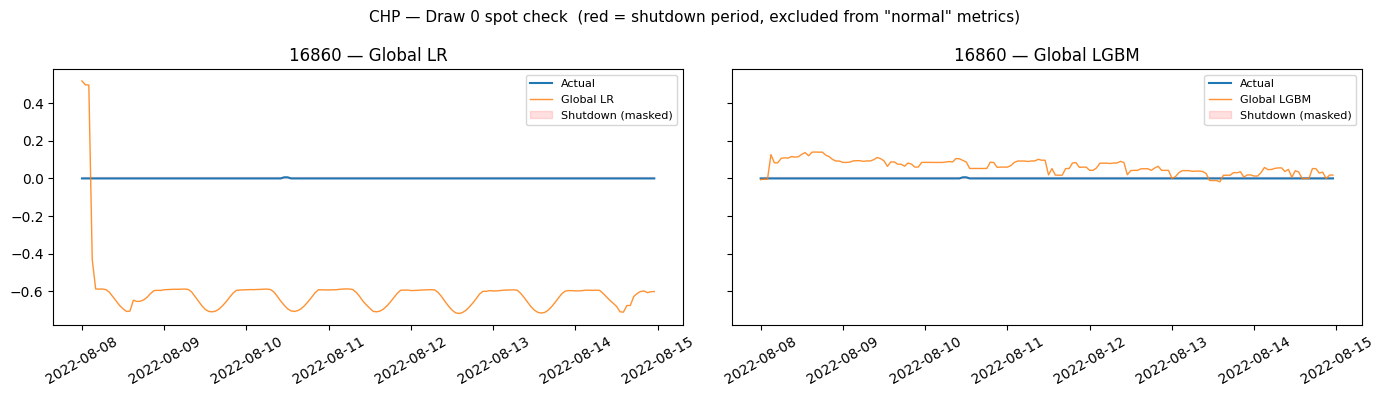


✅ Notebook 05 (CHP) complete — proceed to 06_coherency.ipynb


In [ ]:
# ── Spot check: shutdown event for one unit ──────────────────────────────────
shutdown_uid = None
for uid in forecasts_individual[ID_COL].unique()[:30]:
    yt = forecasts_individual[
        (forecasts_individual[ID_COL]    == uid) &
        (forecasts_individual['approach'] == 'global') &
        (forecasts_individual['model']    == 'LGBM') &
        (forecasts_individual['draw']     == 0)
    ]['y_true'].values
    if (yt <= SHUTDOWN_THRESH).sum() >= SHUTDOWN_MIN_HOURS:
        shutdown_uid = uid
        break

plot_uid = shutdown_uid or forecasts_individual[ID_COL].iloc[0]
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

for ax, model in zip(axes, ['LR', 'LGBM']):
    sub = forecasts_individual[
        (forecasts_individual[ID_COL]    == plot_uid) &
        (forecasts_individual['draw']     == 0) &
        (forecasts_individual['approach'] == 'global') &
        (forecasts_individual['model']    == model)
    ].sort_values('timestamp')

    if len(sub) == 0:
        ax.set_title(f'{plot_uid} — Global {model} (no data)')
        continue

    shutdown_idx = (sub['y_true'] <= SHUTDOWN_THRESH).values.argmax()
    start_idx    = max(0, shutdown_idx - 48)
    sub_plot     = sub.iloc[start_idx : start_idx + 7 * 24]

    ax.plot(sub_plot['timestamp'], sub_plot['y_true'], label='Actual', lw=1.5)
    ax.plot(sub_plot['timestamp'], sub_plot['y_pred'], label=f'Global {model}',
            lw=1, alpha=0.85)
    sd_mask_plot = sub_plot['y_true'] <= SHUTDOWN_THRESH
    ax.fill_between(sub_plot['timestamp'], 0, sub_plot['y_true'].max(),
                    where=sd_mask_plot, alpha=0.12, color='red',
                    label='Shutdown (masked)')
    ax.set_title(f'{plot_uid} — Global {model}')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(
    'CHP — Draw 0 spot check  (red = shutdown period, excluded from "normal" metrics)',
    fontsize=11,
)
plt.tight_layout()
plt.show()
print('\n✅ Notebook 05 (CHP) complete — proceed to 06_coherency.ipynb')

In [ ]:
print('\n✅ Notebook 05 (CHP) complete — proceed to 06_coherency.ipynb')
print('   Section 14.2 (direct-model aggregate metrics) is the canonical')
print('   baseline used by Table 4 and by nb07 reconciliation.')


✅ Notebook 05 (CHP) complete — proceed to 06_coherency.ipynb
   Section 14.2 (direct-model aggregate metrics) is the canonical
   baseline used by Table 4 and by nb07 reconciliation.
